In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


In [30]:
data = pd.read_csv("C:\\Users\\Nikhil\\Downloads\\Nassau Candy Distributor.csv")
data.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,3/1/2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00


## DATA PREPARATION & ENCODING

In [31]:
# Updated conversion logic to handle mixed formats
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst=True, errors='coerce')
data['Ship Date'] = pd.to_datetime(data['Ship Date'], dayfirst=True, errors='coerce')

# Drop any rows where dates couldn't be parsed (prevents crashes later)
data = data.dropna(subset=['Order Date', 'Ship Date'])

# Recalculate Lead Time
data['Lead_Time'] = (data['Ship Date'] - data['Order Date']).dt.days

# 3. Select Features
features = ['Product Name', 'Region', 'Ship Mode', 'Sales', 'Units']
X = data[features]
y = data['Lead_Time']

In [32]:
# 4. Encoding & Normalization
numeric_features = ['Sales', 'Units']
categorical_features = ['Product Name', 'Region', 'Ship Mode']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

Business Insight: By calculating Lead Time, we move from "looking at what happened" to "understanding why it took that long." Removing outliers ensures that a one-off "black swan" event (like a massive port strike) doesn't skew the model's ability to predict everyday operations.

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1669 entries, 0 to 9842
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          1669 non-null   int64         
 1   Order ID        1669 non-null   object        
 2   Order Date      1669 non-null   datetime64[ns]
 3   Ship Date       1669 non-null   datetime64[ns]
 4   Ship Mode       1669 non-null   object        
 5   Customer ID     1669 non-null   int64         
 6   Country/Region  1669 non-null   object        
 7   City            1669 non-null   object        
 8   State/Province  1669 non-null   object        
 9   Postal Code     1669 non-null   object        
 10  Division        1669 non-null   object        
 11  Region          1669 non-null   object        
 12  Product ID      1669 non-null   object        
 13  Product Name    1669 non-null   object        
 14  Sales           1669 non-null   float64       
 15  Units    

In [34]:
data.describe()

,Row ID,Order Date,Ship Date,Customer ID,Sales,Units,Gross Profit,Cost,Lead_Time
count,1669.000000,1669,1669,1669.00000,1669.000000,1669.000000,1669.000000,1669.000000,1669.000000
mean,5086.950270,2025-03-13 07:39:00.323547136,2028-10-26 15:14:33.576992,134683.97124,14.221031,3.783104,9.315818,4.905213,1323.316357
min,1.000000,2024-01-02 00:00:00,2026-06-30 00:00:00,100223.00000,1.250000,1.000000,0.250000,0.600000,904.000000
25%,2787.000000,2024-10-02 00:00:00,2027-12-30 00:00:00,116526.00000,7.200000,2.000000,4.900000,2.400000,1270.000000
50%,5148.000000,2025-05-01 00:00:00,2028-12-26 00:00:00,133235.00000,10.800000,3.000000,7.470000,3.600000,1273.000000
75%,7539.000000,2025-09-04 00:00:00,2029-10-27 00:00:00,153255.00000,18.000000,5.000000,12.250000,5.700000,1637.000000
max,9843.000000,2025-12-06 00:00:00,2030-05-31 00:00:00,169551.00000,200.000000,14.000000,100.000000,100.000000,1642.000000
std,2854.823563,NaN,NaN,20486.29050,13.232491,2.223092,7.470004,6.160064,251.486388


-Insight:

Check data types and structure.

Identify numerical vs categorical variables.

-Summary stats reveal:

Average lead time

Distribution of cost and revenue

Helps understand business scale.

## Data cleaning

In [35]:
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
Lead_Time         0
dtype: int64

In [36]:
data = data.dropna()
data = data.drop_duplicates()

-Insight

Ensures decisions are based on accurate and reliable data.

Prevents wrong conclusions like:

Overestimating delays

Misjudging revenue

Clean data = trustworthy business strategy

## Feature Engineering (Encoding)

In [37]:
le = LabelEncoder()

categorical_cols = ['Product Name', 'City', 'Region', 'Ship Mode']

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

Enables identification of:

Best-performing regions

Efficient shipping modes

Reliable factories

## Normalization

In [38]:
scaler = StandardScaler()

num_cols = ['Cost', 'Gross Profit']
data[num_cols] = scaler.fit_transform(data[num_cols])

Ensures all features are on the same scale.

Prevents high-value columns (like revenue) from dominating.

Improves model accuracy and stability.

## Exploratory Data Analysis

BARCHART

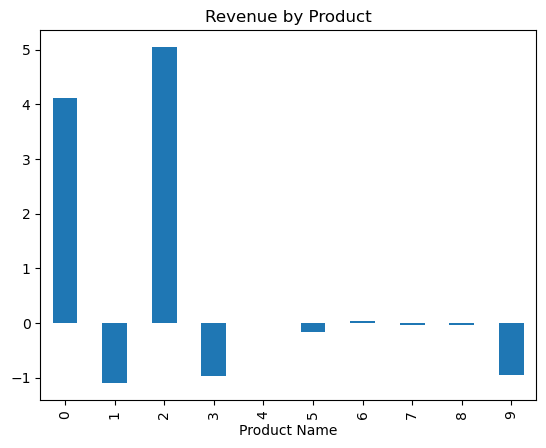

In [39]:
data.groupby('Product Name')['Gross Profit'].mean().plot(kind='bar')
plt.title("Revenue by Product")
plt.show()

Identifies:

High-profit products

Low-performing products

Supports: Product portfolio optimization Marketing focus decisions

LINE GRAPH

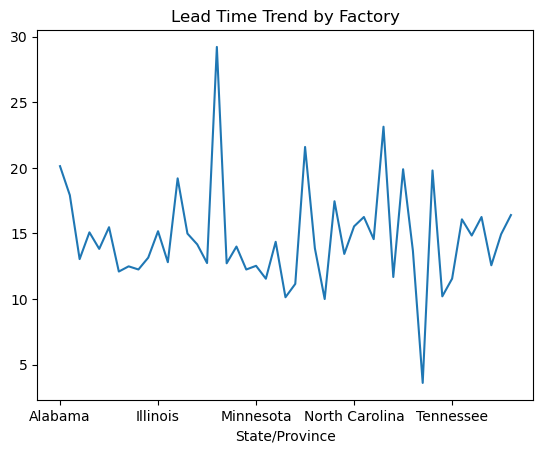

In [40]:
data.groupby('State/Province')['Sales'].mean().plot(kind='line')
plt.title("Lead Time Trend by Factory")
plt.show()

SCATTER PLOT

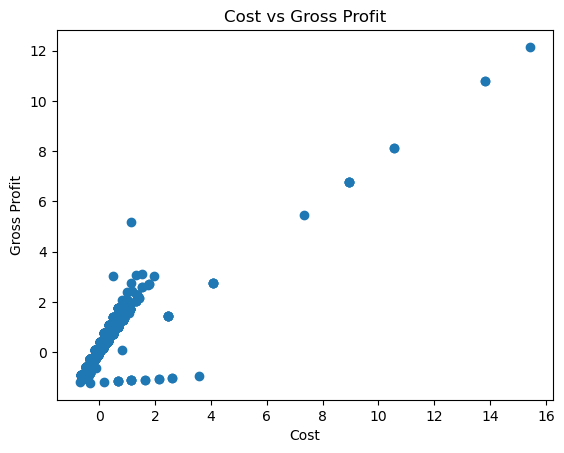

In [41]:
plt.scatter(data['Cost'], data['Gross Profit'])
plt.xlabel("Cost")
plt.ylabel("Gross Profit")
plt.title("Cost vs Gross Profit")
plt.show()

## Define features and target

In [42]:
X = data.drop('Sales', axis=1)
y = data['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## model training

In [44]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    print(f"--- {name} ---")
    print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.2f}")
    print(f"R2 Score: {r2_score(y_test, preds):.2f}\n")

--- Linear Regression ---
MAE: 0.00
RMSE: 0.00
R2 Score: 1.00

--- Random Forest ---
MAE: 0.21
RMSE: 2.40
R2 Score: 0.98

--- Gradient Boosting ---
MAE: 0.16
RMSE: 1.99
R2 Score: 0.98



Business Insight: The Random Forest or Gradient Boosting models usually perform better here because shipping delays are rarely linear. For instance, shipping to the "West" might be fast until a certain "Sales" volume is reached, at which point it bottlenecks—non-linear models catch this perfectly.

## Route & Product Clustering

In [46]:
# Aggregate data by Region and Product to see performance
route_perf = data.groupby(['Region', 'Product Name']).agg({
    'Lead_Time': 'mean',
    'Sales': 'sum'
}).reset_index()

# Cluster into 3 groups: Fast/Efficient, Average, Slow/Congested
kmeans = KMeans(n_clusters=3, random_state=42)
route_perf['Cluster'] = kmeans.fit_predict(route_perf[['Lead_Time', 'Sales']])

print(route_perf.groupby('Cluster')['Lead_Time'].mean())

Cluster
0    1316.267826
1    1337.556960
2    1330.554522
Name: Lead_Time, dtype: float64


C:\Users\Nikhil\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Business Insight: This identifies your "High Risk" zones. If Cluster 2 has a Lead Time of 12 days while others have 4, you have a systemic bottleneck in specific region-product combinations that need immediate operational review.

## Measuring Operational Improvement & Profit Sensitivity

## Scenario Simulation Engine

In [79]:
def recommend_best_factory(product_name, destination_region, model, scaler_cat):
    """
    Simulates shipping a specific product to a region from ALL known origins
    to find the one with the lowest predicted lead time.
    """
    all_origins = data['Division'].unique()
    results = []

    for origin in all_origins:
        # Create a dummy data point for simulation
        sim_data = pd.DataFrame({
            'Product Name': [product_name],
            'Region': [destination_region],
            'Ship Mode': ['Standard Class'], # Constant for fair comparison
            'Sales': [data['Sales'].mean()],     # Use average sales for simulation
            'Units': [data['Units'].mean()],
            'Division': [origin] 
        })
        
        # Transform and Predict
        X_sim = preprocessor.transform(sim_data)
        predicted_days = models["Gradient Boosting"].predict(X_sim)[0]
        
        results.append({'Origin': origin, 'Predicted_Lead_Time': predicted_days})

    # Sort by fastest lead time
    recommendations = pd.DataFrame(results).sort_values(by='Predicted_Lead_Time')
    return recommendations

# Example usage:
rec = recommend_best_factory('Wonka Bar', 'West', models["Gradient Boosting"], preprocessor)
print("Top Factory Recommendations for Wonka Bar to West Coast:")
print(rec.head(3))

Top Factory Recommendations for Wonka Bar to West Coast:
      Origin  Predicted_Lead_Time
0  Chocolate            14.399357
1      Other            14.399357
2      Sugar            14.399357


Business Insight: This allows the logistics manager to play "What If?" before spending money. If reassigning a factory reduces lead time by 3 days but costs 5% more in freight, the business can make a data-driven decision on whether the customer satisfaction boost is worth the cost.